#### What user characteristics and betting behaviors are associated with the highest GGR?

In [103]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt

path = kagglehub.dataset_download("emiliencoicaud/sports-betting-profiling-dataset")
df = pd.read_csv(f"{path}/bets.csv", sep=";", encoding='latin-1')

In [39]:
df.sample(5)

,bet_id,user_id,bet_type,sport,odds,is_win,stake,gain,GGR
81181,bet_81182,1084,multiple,Table Tennis,2.14,False,77.80,0.00,77.80
94441,bet_94442,2573,single,Football,1.10,True,231.70,254.87,-23.17
75746,bet_75747,4546,single,Football,1.10,True,34.30,37.73,-3.43
43910,bet_43911,620,single,Tennis,2.21,True,6.35,14.03,-7.68
45116,bet_45117,587,multiple,Football,3.46,True,404.05,1398.01,-993.96


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   bet_id    100000 non-null  object 
 1   user_id   100000 non-null  int64  
 2   bet_type  100000 non-null  object 
 3   sport     100000 non-null  object 
 4   odds      100000 non-null  float64
 5   is_win    100000 non-null  bool   
 6   stake     100000 non-null  float64
 7   gain      100000 non-null  float64
 8   GGR       100000 non-null  float64
dtypes: bool(1), float64(4), int64(1), object(3)
memory usage: 6.2+ MB


In [47]:
df.isnull().sum()

bet_id      0
user_id     0
bet_type    0
sport       0
odds        0
is_win      0
stake       0
gain        0
GGR         0
dtype: int64

In [50]:
df.describe()

,user_id,odds,stake,gain,GGR
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2495.466980,4.700808,132.631652,119.285792,13.345860
std,1437.932303,4.471646,155.385469,423.864572,399.962988
min,1.000000,1.100000,0.100000,0.000000,-20595.230000
25%,1256.000000,1.320000,25.050000,0.000000,-10.822500
50%,2487.000000,3.180000,84.900000,0.000000,20.300000
75%,3735.000000,6.440000,188.850000,66.262500,115.000000
max,5000.000000,62.150000,1000.000000,21054.330000,999.950000


In [54]:
df['GGR'].min()

np.float64(-20595.23)

In [55]:
df['GGR'].max()

np.float64(999.95)

In [206]:
# right here I want to groupby users not bets
neh = df.groupby('user_id')['GGR'].sum()
neh

user_id
1         88.29
2         59.69
3      -1032.42
4        117.08
5       -519.60
         ...   
4996    2175.53
4997    2759.01
4998   -1711.96
4999     776.92
5000     505.59
Name: GGR, Length: 5000, dtype: float64

In [207]:
# I see theres 5000 users
neh.info

<bound method Series.info of user_id
1         88.29
2         59.69
3      -1032.42
4        117.08
5       -519.60
         ...   
4996    2175.53
4997    2759.01
4998   -1711.96
4999     776.92
5000     505.59
Name: GGR, Length: 5000, dtype: float64>

In [213]:
# 10% of those 5000 is 500 and I only want the ones that had the highest GGR
top10per = neh.sort_values(ascending = False)[:500]
top10per

user_id
1173    11970.34
2415    11671.62
3068    11144.62
4154    10325.17
2558     9789.12
          ...   
1959     1898.94
3788     1898.91
3211     1897.17
524      1889.72
3961     1886.31
Name: GGR, Length: 500, dtype: float64

In [247]:
# showing top 10% users in the dataframe betting results
top10df = df[df['user_id'].isin(top10per.index)]


,bet_id,user_id,bet_type,sport,odds,is_win,stake,gain,GGR
1,bet_00002,153,single,Football,8.79,False,248.45,0.00,248.45
4,bet_00005,2290,single,Football,1.47,True,319.05,469.00,-149.95
13,bet_00014,2448,multiple,Tennis,2.75,False,350.55,0.00,350.55
23,bet_00024,2558,single,Football,12.00,False,980.55,0.00,980.55
27,bet_00028,4739,multiple,Snooker,17.04,False,273.95,0.00,273.95
...,...,...,...,...,...,...,...,...,...
99970,bet_99971,1206,single,Football,5.87,False,442.10,0.00,442.10
99971,bet_99972,824,single,Basketball,1.88,True,103.15,193.92,-90.77
99975,bet_99976,2879,single,Football,5.39,False,490.35,0.00,490.35
99982,bet_99983,768,single,Football,1.10,True,118.70,130.57,-11.87


In [253]:
# users who did not win a game
top10dfl = top10df[top10df['is_win'] == False]
top10dfl

,bet_id,user_id,bet_type,sport,odds,is_win,stake,gain,GGR
1,bet_00002,153,single,Football,8.79,False,248.45,0.0,248.45
13,bet_00014,2448,multiple,Tennis,2.75,False,350.55,0.0,350.55
23,bet_00024,2558,single,Football,12.00,False,980.55,0.0,980.55
27,bet_00028,4739,multiple,Snooker,17.04,False,273.95,0.0,273.95
53,bet_00054,2296,single,Ice Hockey,1.90,False,495.80,0.0,495.80
...,...,...,...,...,...,...,...,...,...
99918,bet_99919,3837,multiple,Football,6.61,False,224.05,0.0,224.05
99939,bet_99940,4050,single,Basketball,1.10,False,184.90,0.0,184.90
99964,bet_99965,3383,single,Football,2.86,False,361.90,0.0,361.90
99970,bet_99971,1206,single,Football,5.87,False,442.10,0.0,442.10


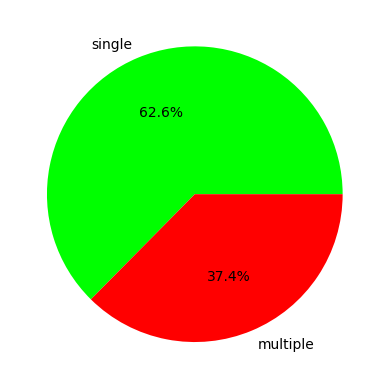

In [274]:
# counting how many placed single or multiple bets
counts_type = top10dfl['bet_type'].value_counts()
fig, ax = plt.subplots()
colors = ['lime', 'red']
ax.pie(counts_type, labels=counts_type.index, autopct='%1.1f%%', colors=colors)
plt.show()

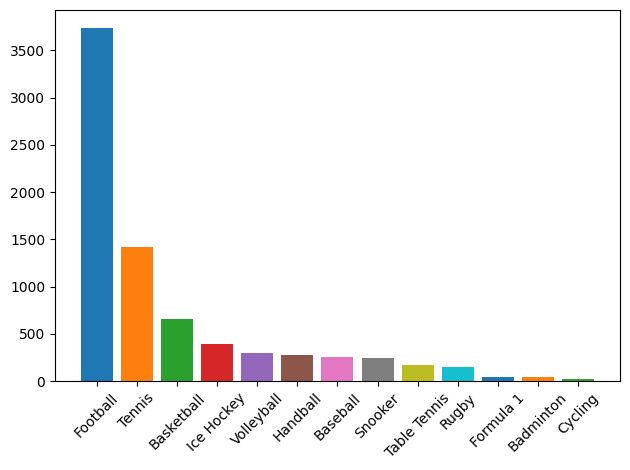

In [275]:
# counting what sports were mostly placed
counts_sport = top10dfl['sport'].value_counts()
fig, ax = plt.subplots()
ax.bar(counts_sport.index, counts_sport.values, color=plt.cm.tab10.colors)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()